## Modelo de entrenamiento de ai para una fintech que permite detectar registros validos.

### Librerias

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,roc_curve, roc_auc_score
)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')


### carga de datos mediante los dataset

In [6]:
dflim=pd.read_csv('fintech_limpio.csv')
print(f'   {dflim.shape[0]}   |  {dflim.shape[1]} ')
print()
dflim.head(6)

   19   |  36 



,transaction_id,created_at,reporting_month,account_id,counterparty_account,transaction_group_id,transaction_type,status,amount,currency,...,val_status_integrity,val_status,val_balance,val_reporting_month,val_amount,val_hash_present,val_hash_chain,val_unique_id,registro_valido,observaciones
0,tx000000-0000-0000-0000-000000000001,2026-01-01 08:00:00+00:00,2026-01,ACC1001,CLIENT-100,GRP-202601-01,CREDIT,COMPLETED,1000.0,USD,...,True,True,True,True,True,True,True,True,True,Registro válido
1,tx000000-0000-0000-0000-000000000002,2026-01-02 09:15:00+00:00,2026-01,ACC1001,VEN-9001,GRP-202601-01,DEBIT,COMPLETED,250.0,USD,...,True,True,True,True,True,True,True,True,True,Registro válido
2,tx000000-0000-0000-0000-000000000003,2026-01-03 10:05:00+00:00,2026-01,ACC1001,CLIENT-451,GRP-202601-02,CREDIT,COMPLETED,500.0,USD,...,True,True,True,True,True,True,True,True,True,Registro válido
3,tx000000-0000-0000-0000-000000000004,2026-01-04 11:00:00+00:00,2026-01,ACC1001,,GRP-202601-03,FEE,COMPLETED,5.0,USD,...,True,True,True,True,True,True,True,True,True,Registro válido
4,tx000000-0000-0000-0000-000000000006,2026-01-06 13:45:00+00:00,2026-01,ACC1002,MERCH-202,GRP-202601-11,DEBIT,COMPLETED,85.5,USD,...,True,True,True,True,True,True,True,True,True,Registro válido
5,tx000000-0000-0000-0000-000000000008,2026-01-08 15:30:00+00:00,2026-01,ACC1003,CLIENT-333,GRP-202601-21,CREDIT,COMPLETED,150.0,USD,...,True,True,True,True,True,True,True,True,True,Registro válido


In [7]:
dfinv=pd.read_csv('fintech_invalidos.csv')
print(f'   {dfinv.shape[0]}   |  {dfinv.shape[1]} ')
print()
dfinv.head(6)

   141   |  36 



,transaction_id,created_at,reporting_month,account_id,counterparty_account,transaction_group_id,transaction_type,status,amount,currency,...,val_status_integrity,val_status,val_balance,val_reporting_month,val_amount,val_hash_present,val_hash_chain,val_unique_id,registro_valido,observaciones
0,tx000000-0000-0000-0000-000000000005,2026-01-05 12:30:00+00:00,2026-01,ACC1002,CLIENT-771,GRP-202601-10,CREDIT,COMPLETED,1200.00,USD,...,True,True,True,True,True,True,False,True,False,Cadena de hashes inválida
1,tx000000-0000-0000-0000-000000000007,2026-01-07 14:20:00+00:00,2026-01,ACC1003,CLIENT-222,GRP-202601-20,DEBIT,COMPLETED,45.00,USD,...,True,True,True,True,True,True,False,True,False,Cadena de hashes inválida
2,tx000000-0000-0000-0000-000000000009,2026-01-09 16:40:00+00:00,2026-01,ACC1004,MERCH-777,GRP-202601-30,DEBIT,COMPLETED,99.99,USD,...,True,True,True,True,True,True,False,True,False,Cadena de hashes inválida
3,tx000000-0000-0000-0000-00000000000C,2026-01-12 11:25:00+00:00,2026-01,ACC1006,CLIENT-888,GRP-202601-40,CREDIT,COMPLETED,450.00,USD,...,True,True,True,True,True,True,False,True,False,Cadena de hashes inválida
4,tx000000-0000-0000-0000-00000000000E,2026-01-14 13:45:00+00:00,2026-01,ACC1007,CLIENT-999,GRP-202601-50,CREDIT,COMPLETED,200.00,USD,...,True,True,True,True,True,True,False,True,False,Cadena de hashes inválida
5,tx000000-0000-0000-0000-000000000010,2026-01-16 15:05:00+00:00,2026-01,ACC1008,CLIENT-222,GRP-202601-60,CREDIT,COMPLETED,130.00,USD,...,True,True,True,True,True,True,False,True,False,Cadena de hashes inválida


In [8]:
print(' Información general:')
print(dflim.info())
print()
print(' Estadísticas descriptivas:')
dflim.describe().round(2)

 Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 36 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   transaction_id        19 non-null     object 
 1   created_at            19 non-null     object 
 2   reporting_month       19 non-null     object 
 3   account_id            19 non-null     object 
 4   counterparty_account  19 non-null     object 
 5   transaction_group_id  19 non-null     object 
 6   transaction_type      19 non-null     object 
 7   status                19 non-null     object 
 8   amount                19 non-null     float64
 9   currency              19 non-null     object 
 10  balance_before        19 non-null     float64
 11  balance_after         19 non-null     float64
 12  regulatory_code       19 non-null     object 
 13  finalized             19 non-null     bool   
 14  record_hash           19 non-null     object 
 15  pre

,amount,balance_before,balance_after,amount_signed,balance_delta,monto_firmado
count,19.00,19.00,19.00,19.00,19.00,19.00
mean,151.92,2172.37,2225.71,53.34,53.34,53.34
std,239.75,2092.87,2213.51,280.78,280.78,280.78
min,5.00,100.00,90.01,-250.00,-250.00,-250.00
25%,30.00,700.00,665.00,-67.62,-67.62,-67.62
50%,60.00,1100.00,1024.75,-30.00,-30.00,-30.00
75%,135.00,3077.50,3109.75,-7.50,-7.49,-7.50
max,1000.00,6250.00,6250.00,1000.00,1000.00,1000.00


In [9]:
print(' Información general:')
print(dfinv.info())
print()
print(' Estadísticas descriptivas:')
dfinv.describe().round(2)

 Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 36 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   transaction_id        141 non-null    object 
 1   created_at            140 non-null    object 
 2   reporting_month       141 non-null    object 
 3   account_id            141 non-null    object 
 4   counterparty_account  141 non-null    object 
 5   transaction_group_id  141 non-null    object 
 6   transaction_type      141 non-null    object 
 7   status                141 non-null    object 
 8   amount                140 non-null    float64
 9   currency              141 non-null    object 
 10  balance_before        141 non-null    float64
 11  balance_after         140 non-null    float64
 12  regulatory_code       141 non-null    object 
 13  finalized             141 non-null    bool   
 14  record_hash           141 non-null    object 
 15  p

,amount,balance_before,balance_after,amount_signed,balance_delta,monto_firmado
count,140.00,141.00,140.00,140.00,140.00,140.00
mean,305.76,1673.02,1862.43,182.60,183.31,182.60
std,409.12,1609.75,1649.22,477.45,477.17,477.45
min,-50.00,50.00,53.52,-3000.00,-3000.00,-3000.00
25%,39.75,543.00,598.75,-40.00,-39.25,-40.00
50%,165.00,1020.00,1342.50,37.50,62.50,37.50
75%,412.50,2470.00,2731.25,400.00,400.00,400.00
max,3000.00,9250.00,9250.00,2000.00,2000.00,2000.00


In [10]:
print(' Valores nulos por columna limpio:')
dflim['metadata_channel'] = dflim['metadata_channel'].fillna('UNKNOWN')
print(dflim.isnull().sum())
print()

print(' Valores nulos por columna invalidos:')
print(dfinv.isnull().sum())
print()


 Valores nulos por columna limpio:
transaction_id          0
created_at              0
reporting_month         0
account_id              0
counterparty_account    0
transaction_group_id    0
transaction_type        0
status                  0
amount                  0
currency                0
balance_before          0
balance_after           0
regulatory_code         0
finalized               0
record_hash             0
prev_record_hash        0
metadata                0
_ingested_at            0
amount_signed           0
balance_delta           0
metadata_channel        0
metadata_note           0
created_date            0
created_month           0
monto_firmado           0
val_status_known        0
val_status_integrity    0
val_status              0
val_balance             0
val_reporting_month     0
val_amount              0
val_hash_present        0
val_hash_chain          0
val_unique_id           0
registro_valido         0
observaciones           0
dtype: int64

 Valores nulos 

In [11]:
dftotal = pd.concat([dflim, dfinv], ignore_index=True)
dftotal['registro_valido'].value_counts()
print(dftotal.isnull().sum())


transaction_id            0
created_at                1
reporting_month           0
account_id                0
counterparty_account      0
transaction_group_id      0
transaction_type          0
status                    0
amount                    1
currency                  0
balance_before            0
balance_after             1
regulatory_code           0
finalized                 0
record_hash               0
prev_record_hash          0
metadata                  0
_ingested_at              0
amount_signed             1
balance_delta             1
metadata_channel        120
metadata_note             0
created_date              1
created_month             1
monto_firmado             1
val_status_known          0
val_status_integrity      0
val_status                0
val_balance               0
val_reporting_month       0
val_amount                0
val_hash_present          0
val_hash_chain            0
val_unique_id             0
registro_valido           0
observaciones       

In [12]:
dftotal

,transaction_id,created_at,reporting_month,account_id,counterparty_account,transaction_group_id,transaction_type,status,amount,currency,...,val_status_integrity,val_status,val_balance,val_reporting_month,val_amount,val_hash_present,val_hash_chain,val_unique_id,registro_valido,observaciones
0,tx000000-0000-0000-0000-000000000001,2026-01-01 08:00:00+00:00,2026-01,ACC1001,CLIENT-100,GRP-202601-01,CREDIT,COMPLETED,1000.0,USD,...,True,True,True,True,True,True,True,True,True,Registro válido
1,tx000000-0000-0000-0000-000000000002,2026-01-02 09:15:00+00:00,2026-01,ACC1001,VEN-9001,GRP-202601-01,DEBIT,COMPLETED,250.0,USD,...,True,True,True,True,True,True,True,True,True,Registro válido
2,tx000000-0000-0000-0000-000000000003,2026-01-03 10:05:00+00:00,2026-01,ACC1001,CLIENT-451,GRP-202601-02,CREDIT,COMPLETED,500.0,USD,...,True,True,True,True,True,True,True,True,True,Registro válido
3,tx000000-0000-0000-0000-000000000004,2026-01-04 11:00:00+00:00,2026-01,ACC1001,,GRP-202601-03,FEE,COMPLETED,5.0,USD,...,True,True,True,True,True,True,True,True,True,Registro válido
4,tx000000-0000-0000-0000-000000000006,2026-01-06 13:45:00+00:00,2026-01,ACC1002,MERCH-202,GRP-202601-11,DEBIT,COMPLETED,85.5,USD,...,True,True,True,True,True,True,True,True,True,Registro válido
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,tx000000-0000-0000-0000-00000000009C,2026-06-10 08:40:00+00:00,2026-06,ACC1002,CLIENT-771,GRP-202606-10,CREDIT,COMPLETED,250.0,USD,...,True,True,True,True,True,True,False,True,False,Cadena de hashes inválida
156,tx000000-0000-0000-0000-00000000009D,2026-06-11 09:50:00+00:00,2026-06,ACC1003,CLIENT-222,GRP-202606-11,DEBIT,COMPLETED,95.0,USD,...,True,True,True,True,True,True,False,True,False,Cadena de hashes inválida
157,tx000000-0000-0000-0000-00000000009E,2026-06-12 10:00:00+00:00,2026-06,ACC1004,MERCH-777,GRP-202606-12,DEBIT,COMPLETED,55.0,USD,...,True,True,True,True,True,True,False,True,False,Cadena de hashes inválida
158,tx000000-0000-0000-0000-00000000009F,2026-06-13 11:10:00+00:00,2026-06,ACC1005,CLIENT-555,GRP-202606-13,CREDIT,COMPLETED,260.0,USD,...,True,True,True,True,True,True,False,True,False,Cadena de hashes inválida


 Variable objetivo: registro_valido
   registro invalido (0): 141 clientes (88.1%)
   registro valido (1): 19 clientes (11.9%)


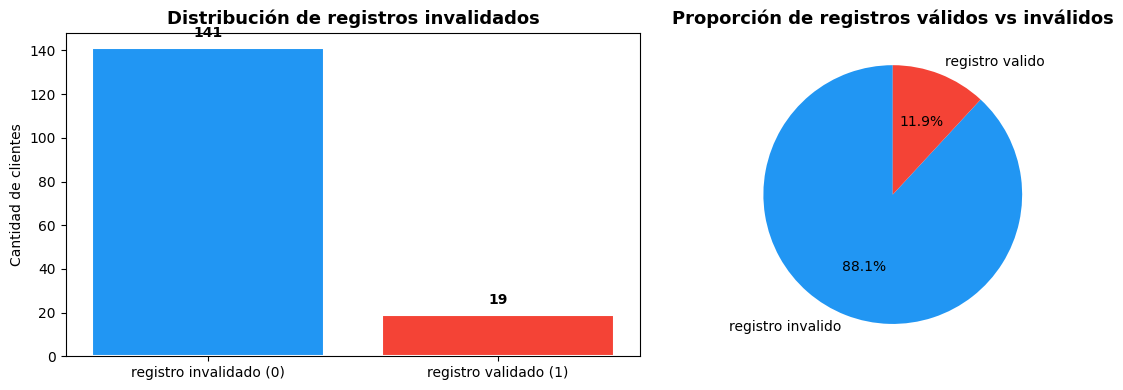

In [13]:
conteo = dftotal['registro_valido'].value_counts()
pct    = dftotal['registro_valido'].value_counts(normalize=True) * 100

print(' Variable objetivo: registro_valido')
print(f'   registro invalido (0): {conteo[0]} clientes ({pct[0]:.1f}%)')
print(f'   registro valido (1): {conteo[1]} clientes ({pct[1]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))


colores = ['#2196F3', '#F44336']
axes[0].bar(['registro invalidado (0)', 'registro validado (1)'], conteo.values,
            color=colores, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribución de registros invalidados', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de clientes')
for i, v in enumerate(conteo.values):
   axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(conteo.values, labels=['registro invalido', 'registro valido'],
            autopct='%1.1f%%', colors=colores, startangle=90)
axes[1].set_title('Proporción de registros válidos vs inválidos', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## **Seleccionar Variables**

In [14]:
#Seleccionar Variables

X = dftotal.drop(columns=[
    'registro_valido',

    # VALIDACIONES DIRECTAS
    'transaction_id',
    'account_id',
    'counterparty_account',
    'transaction_group_id',
    'record_hash',
    'prev_record_hash',

    # Fechas y Auditoría (Confunden al modelo o se repiten)
    'created_at',
    '_ingested_at',
    'created_date',
    'created_month',

    # Textos y Notas de error (Hacen trampa / Data Leakage masivo)
    'observaciones',
    'metadata',
    'metadata_note',

    # Columnas de Validación prefabricadas (Hacen trampa / Data Leakage)
    'val_status_known',
    'val_status_integrity',
    'val_status',
    'val_balance',
    'val_reporting_month',
    'val_amount',
    'val_hash_present',
    'val_hash_chain',
    'val_unique_id'
], errors='ignore')

y=dftotal['registro_valido']
# Limpiar nulos primero
X = X.copy()

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = X[col].fillna('unknown')
    else:
        X[col] = X[col].fillna(0)

# Luego encoding
X = pd.get_dummies(X, drop_first=True)

print(' Valores nulos por columna:')
print(X.isnull().sum())
print('\n Distribución del target:')
print(y.value_counts())

print(' Variables seleccionadas:')
print(f'   Variables predictoras (X): {list(X.columns)}')
print(f'   Variable objetivo    (y) : registro_valido')
print()
print(f'   Dimensiones de X: {X.shape}')
print(f'   Dimensiones de y: {y.shape}')



 Valores nulos por columna:
amount                      0
balance_before              0
balance_after               0
finalized                   0
amount_signed               0
balance_delta               0
monto_firmado               0
reporting_month_2026-02     0
reporting_month_2026-03     0
reporting_month_2026-04     0
reporting_month_2026-05     0
reporting_month_2026-06     0
transaction_type_DEBIT      0
transaction_type_FEE        0
status_FAILED               0
currency_USD                0
regulatory_code_RPT02       0
metadata_channel_ATM        0
metadata_channel_BANK       0
metadata_channel_CARD       0
metadata_channel_HR         0
metadata_channel_PAYPAL     0
metadata_channel_SYSTEM     0
metadata_channel_TEST       0
metadata_channel_UNKNOWN    0
metadata_channel_WIRE       0
metadata_channel_unknown    0
dtype: int64

 Distribución del target:
registro_valido
False    141
True      19
Name: count, dtype: int64
 Variables seleccionadas:
   Variables predictoras (X)

## **Dividir en Entrenamiento y Prueba**

In [15]:
#Dividir en Entrenamiento y Prueba

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Antes de SMOTE - Entrenamiento: {y_train.value_counts().to_dict()}")

smote = SMOTE(k_neighbors=4, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Después de SMOTE - Entrenamiento: {y_train_res.value_counts().to_dict()}")



print(' División completada:')
print(f'   Total de registros : {len(dftotal)}')
print(f'   Entrenamiento      : {len(X_train)} registros ({len(X_train)/len(dftotal)*100:.0f}%)')
print(f'   Prueba             : {len(X_test)}  registros ({len(X_test)/len(dftotal)*100:.0f}%)')
print()
print(' Balance de clases por conjunto:')
print(f'   Entrenamiento → registro_valido: {y_train.mean()*100:.1f}%')
print(f'   Prueba        → registro_valido: {y_test.mean()*100:.1f}%')

Antes de SMOTE - Entrenamiento: {False: 113, True: 15}
Después de SMOTE - Entrenamiento: {False: 113, True: 113}
 División completada:
   Total de registros : 160
   Entrenamiento      : 128 registros (80%)
   Prueba             : 32  registros (20%)

 Balance de clases por conjunto:
   Entrenamiento → registro_valido: 11.7%
   Prueba        → registro_valido: 12.5%


## **Construir el Modelo**

In [16]:
modelo = LogisticRegression(
    penalty='l2',
    max_iter=100,
    random_state=42,
    class_weight='balanced'
)

print('Modelo construido (aún NO entrenado):')
print(f'   Algoritmo      : Regresión Logística')
print(f'   Regularización : L2 (Ridge)')
print(f'   Max iteraciones: 100')
print()
print(modelo)

Modelo construido (aún NO entrenado):
   Algoritmo      : Regresión Logística
   Regularización : L2 (Ridge)
   Max iteraciones: 100

LogisticRegression(class_weight='balanced', random_state=42)


## **Entrenar el Modelo**

In [17]:
modelo.fit(X_train_res, y_train_res)

print(' ¡Modelo entrenado exitosamente!')
print()
print(' Coeficientes aprendidos por el modelo:')
coeficientes = pd.DataFrame({
    'Variable' : X.columns,
    'Coeficiente' : modelo.coef_[0].round(4)
}).sort_values('Coeficiente', ascending=False)
print(coeficientes.to_string(index=False))
print()
print(' Coeficiente positivo → aumenta la probabilidad de registros validados')
print(' Coeficiente negativo → disminuye la probabilidad de registros invalidos')

 ¡Modelo entrenado exitosamente!

 Coeficientes aprendidos por el modelo:
                Variable  Coeficiente
metadata_channel_UNKNOWN       2.6028
           monto_firmado       1.1705
           amount_signed       1.1705
   metadata_channel_CARD       1.0255
  transaction_type_DEBIT       0.3106
           balance_after       0.0782
    transaction_type_FEE       0.0655
 metadata_channel_SYSTEM       0.0655
   regulatory_code_RPT02       0.0655
           status_FAILED       0.0000
     metadata_channel_HR      -0.0004
 metadata_channel_PAYPAL      -0.0017
    metadata_channel_ATM      -0.0040
                  amount      -0.0079
   metadata_channel_BANK      -0.0278
               finalized      -0.0551
            currency_USD      -0.0551
   metadata_channel_TEST      -0.0658
   metadata_channel_WIRE      -0.0713
          balance_before      -0.0776
 reporting_month_2026-06      -0.3180
 reporting_month_2026-02      -0.3415
 reporting_month_2026-03      -0.6420
 reporting_mon

## **Evaluar el Modelo**

In [18]:
y_pred = modelo.predict(X_test)

accuracy  = accuracy_score(y_test, y_pred)  # compara todo
precision = precision_score(y_test, y_pred) # compara los que predijo como positivos
recall    = recall_score(y_test, y_pred)    # compara los positivos reales
f1        = f1_score(y_test, y_pred)        # combina precision y recall

# Métricas (registro inválido = 0)
precision_inv = precision_score(y_test, y_pred, pos_label=0)
recall_inv    = recall_score(y_test, y_pred, pos_label=0)

print(' MÉTRICAS DE EVALUACIÓN7')
print('=' * 70)
print(f'  Accuracy  (Exactitud) : {accuracy*100:.1f}%')
print(f'  Precision             : {precision*100:.1f}%')
print(f'  Recall (Sensibilidad) : {recall*100:.1f}%')
print(f'  F1-Score              : {f1*100:.1f}%')
print()
print('=' * 70)
print('\n Evaluación para registros INVÁLIDOS:')
print(f'  Precision (inválidos): {precision_inv*100:.1f}%')
print(f'  Recall    (inválidos): {recall_inv*100:.1f}%')
print()
print('=' * 70)
print('\n Matriz de confusión:')
print(confusion_matrix(y_test, y_pred))
print()
print('=' * 70)
print(' Interpretación:')
print(f'  De cada 100 registros, el modelo acierta {accuracy*100:.0f}')
print(f'  De los registros válidos reales, detecta el {recall*100:.0f}%')
print(f'  Cuando predice un registro válido, acierta el {precision*100:.0f}% de las veces')
print(f'  De los registros inválidos reales, detecta el {recall_inv*100:.0f}%')
print(f'  Cuando predice un registro inválido, acierta el {precision_inv*100:.0f}% de las veces')
print()
print('=' * 70)

 MÉTRICAS DE EVALUACIÓN7
  Accuracy  (Exactitud) : 87.5%
  Precision             : 50.0%
  Recall (Sensibilidad) : 50.0%
  F1-Score              : 50.0%


 Evaluación para registros INVÁLIDOS:
  Precision (inválidos): 92.9%
  Recall    (inválidos): 92.9%


 Matriz de confusión:
[[26  2]
 [ 2  2]]

 Interpretación:
  De cada 100 registros, el modelo acierta 88
  De los registros válidos reales, detecta el 50%
  Cuando predice un registro válido, acierta el 50% de las veces
  De los registros inválidos reales, detecta el 93%
  Cuando predice un registro inválido, acierta el 93% de las veces



## **MATRIZ DE CONFUSIÓN**

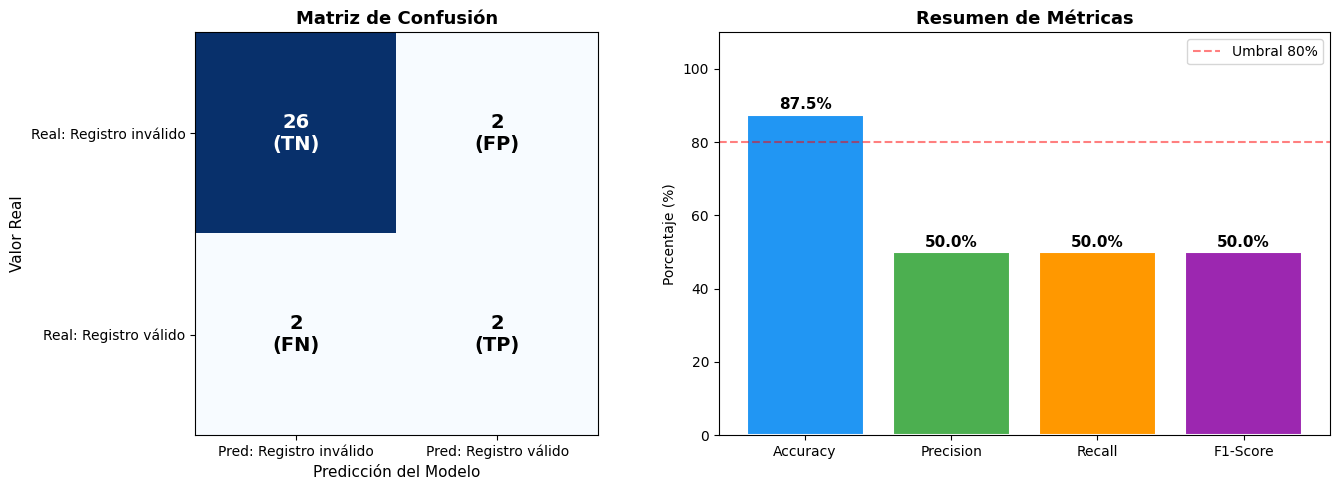



 Métricas por clase:

                   precision    recall  f1-score   support

Registro inválido       0.93      0.93      0.93        28
  Registro válido       0.50      0.50      0.50         4

         accuracy                           0.88        32
        macro avg       0.71      0.71      0.71        32
     weighted avg       0.88      0.88      0.88        32




In [19]:
#matriz de confusion
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
axes[0].imshow(cm, interpolation='nearest', cmap='Blues')
axes[0].set_title('Matriz de Confusión', fontsize=13, fontweight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred: Registro inválido', 'Pred: Registro válido'])
axes[0].set_yticklabels(['Real: Registro inválido', 'Real: Registro válido'])
axes[0].set_ylabel('Valor Real', fontsize=11)
axes[0].set_xlabel('Predicción del Modelo', fontsize=11)

etiquetas = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f'{cm[i, j]}\n({etiquetas[i][j]})',
                     ha='center', va='center', fontsize=14, fontweight='bold',
                     color='white' if cm[i, j] > cm.max()/2 else 'black')

# Barras de métricas
metricas_nombres = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
valores          = [accuracy, precision, recall, f1]
colores_m        = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

bars = axes[1].bar(metricas_nombres, [v*100 for v in valores],
                   color=colores_m, edgecolor='white', linewidth=1.5)
axes[1].set_ylim(0, 110)
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_title('Resumen de Métricas', fontsize=13, fontweight='bold')
axes[1].axhline(y=80, color='red', linestyle='--', alpha=0.5, label='Umbral 80%')
axes[1].legend()

for bar, val in zip(bars, valores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{val*100:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print()
print('\n Métricas por clase:')
print()
print('=' * 80)
print(classification_report(y_test, y_pred, target_names=['Registro inválido', 'Registro válido']))
print()
print('=' * 80)

## **Comparar con Árbol de Decisión**

In [21]:

# MODELO ÁRBOL
arbol = DecisionTreeClassifier(max_depth=5, random_state=42)
arbol.fit(X_train, y_train)
y_pred_arbol = arbol.predict(X_test)


# COMPARACIÓN
print(' COMPARACIÓN DE ALGORITMOS')
print('=' * 65)
print(f'{"Métrica":<30} {"Reg. Logística":>14} {"Árbol":>14}')
print('-' * 65)

metricas_comp = {
    'Accuracy' : (
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_arbol)
    ),
    'Precision (válidos)' : (
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_arbol)
    ),
    'Recall (válidos)' : (
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_arbol)
    ),
    'Precision (inválidos)' : (
        precision_score(y_test, y_pred, pos_label=0),
        precision_score(y_test, y_pred_arbol, pos_label=0)
    ),
    'Recall (inválidos)' : (
        recall_score(y_test, y_pred, pos_label=0),
        recall_score(y_test, y_pred_arbol, pos_label=0)
    ),
    'F1-Score' : (
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_arbol)
    ),
}

for nombre, (v1, v2) in metricas_comp.items():
    mejor1 = '' if v1 >= v2 else '  '
    mejor2 = '' if v2 > v1  else '  '
    print(f'{nombre:<30} {mejor1}{v1*100:>10.1f}%   {mejor2}{v2*100:>10.1f}%')

print('=' * 65)

 COMPARACIÓN DE ALGORITMOS
Métrica                        Reg. Logística          Árbol
-----------------------------------------------------------------
Accuracy                               87.5%         93.8%
Precision (válidos)                    50.0%         75.0%
Recall (válidos)                       50.0%         75.0%
Precision (inválidos)                  92.9%         96.4%
Recall (inválidos)                     92.9%         96.4%
F1-Score                               50.0%         75.0%


## **curva roc y coef gini.**

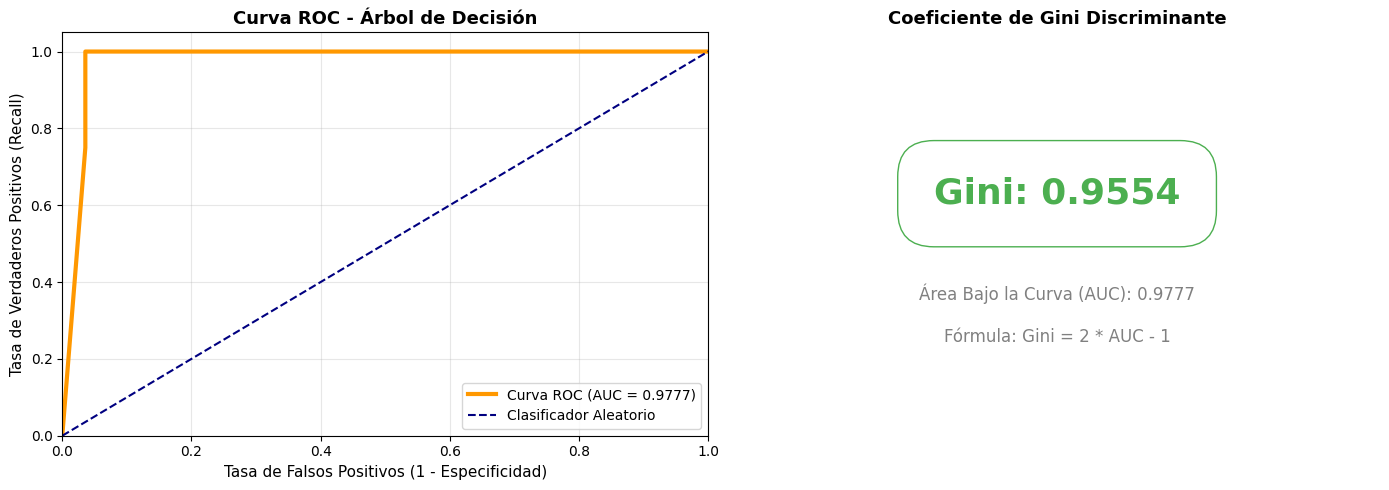

 Coeficiente de Gini Oficial para el Informe: 0.9554


In [26]:
y_probs_arbol = arbol.predict_proba(X_test)[:, 1]

# 2. Calcular AUC ROC y el Coeficiente de Gini matemático
auc_roc_arbol = roc_auc_score(y_test, y_probs_arbol)
gini_arbol = 2 * auc_roc_arbol - 1

# 3. Crear el gráfico complementario (Estilo similar al tuyo)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel Izquierdo: Gráfico de la Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs_arbol)
axes[0].plot(fpr, tpr, color='#FF9800', lw=3, label=f'Curva ROC (AUC = {auc_roc_arbol:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Clasificador Aleatorio')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11)
axes[0].set_ylabel('Tasa de Verdaderos Positivos (Recall)', fontsize=11)
axes[0].set_title('Curva ROC - Árbol de Decisión', fontsize=13, fontweight='bold')
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# Panel Derecho: Cuadro informativo de Gini (Exigido en el informe)
axes[1].text(0.5, 0.6, f'Gini: {gini_arbol:.4f}',
             ha='center', va='center', fontsize=26, fontweight='bold', color='#4CAF50',
             bbox=dict(facecolor='none', edgecolor='#4CAF50', boxstyle='round,pad=1'))
axes[1].text(0.5, 0.3, f'Área Bajo la Curva (AUC): {auc_roc_arbol:.4f}\n\nFórmula: Gini = 2 * AUC - 1',
             ha='center', va='center', fontsize=12, color='gray')
axes[1].set_title('Coeficiente de Gini Discriminante', fontsize=13, fontweight='bold')
axes[1].axis('off') # Ocultamos los ejes para dejarlo como tarjeta informativa

plt.tight_layout()
plt.show()

print('=' * 80)
print(f' Coeficiente de Gini Oficial para el Informe: {gini_arbol:.4f}')
print('=' * 80)